https://www.kaggle.com/datasets/chebotinaa/fast-food-marketing-campaign-ab-test

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pingouin as pg
from scikit_posthocs import posthoc_dunn
import numpy as np

In [2]:
df = pd.read_csv(r'data/WA_Marketing-Campaign.csv')
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [3]:
df.MarketSize.nunique()

3

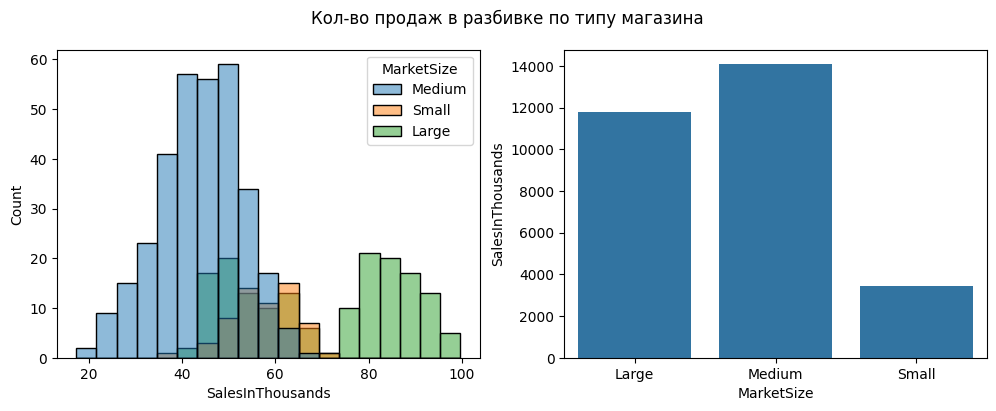

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df, x='SalesInThousands', hue='MarketSize', ax=ax[0]) 
sns.barplot(df.groupby('MarketSize').SalesInThousands.sum())
plt.suptitle('Кол-во продаж в разбивке по типу магазина');

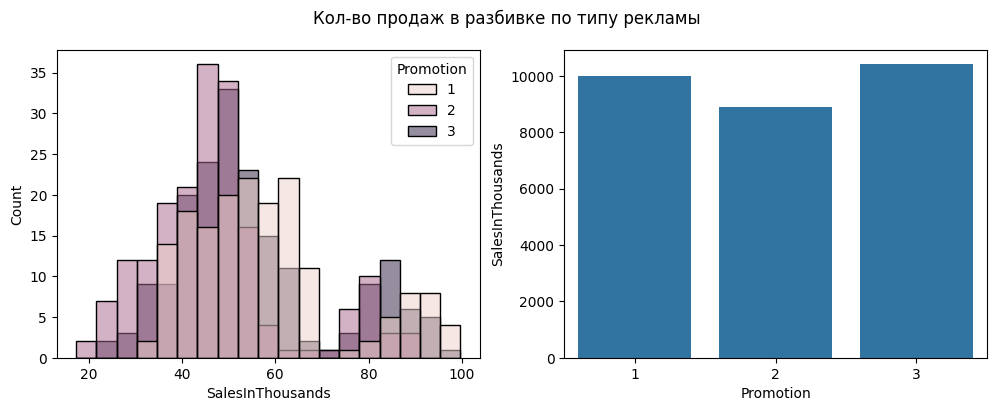

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df, x='SalesInThousands', hue='Promotion', ax=ax[0]) 
sns.barplot(df.groupby('Promotion').SalesInThousands.sum())
plt.suptitle('Кол-во продаж в разбивке по типу рекламы');

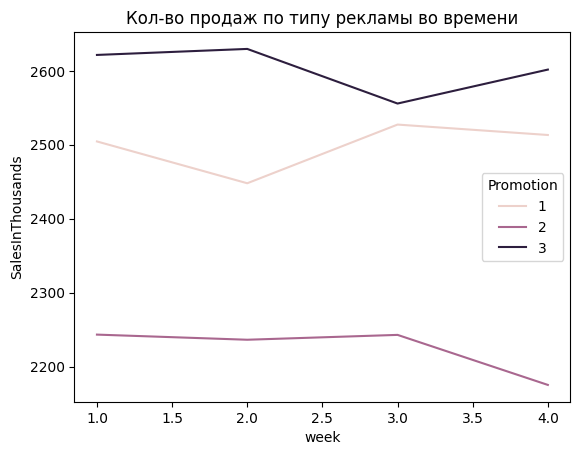

In [6]:
tmp = df.groupby(['week', 'Promotion'], as_index=False).agg(SalesInThousands=('SalesInThousands', pd.Series.sum))

sns.lineplot(tmp, x='week', y='SalesInThousands', hue='Promotion', errorbar=None)
plt.title('Кол-во продаж по типу рекламы во времени');

Проверим, есть ли зависимость продаж от market size. Воспользуемся для начала [ANOVA](https://ru.wikipedia.org/wiki/%D0%94%D0%B8%D1%81%D0%BF%D0%B5%D1%80%D1%81%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7).

H0: $\mu_{small} = \mu_{medium} = \mu_{large}$

H1: Как минимум, средние в каких-то двух группах отличаются.

In [7]:
df.groupby('MarketSize').SalesInThousands.mean()

MarketSize
Large     70.116726
Medium    43.985344
Small     57.409333
Name: SalesInThousands, dtype: float64

In [8]:
medium = df[df.MarketSize == 'Medium'].SalesInThousands
small = df[df.MarketSize == 'Small'].SalesInThousands
large = df[df.MarketSize == 'Large'].SalesInThousands

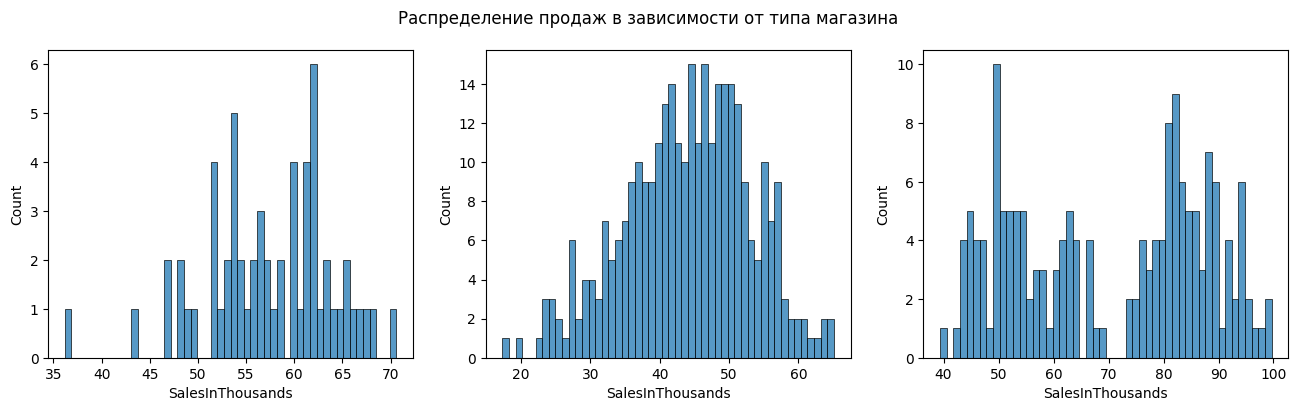

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(small, bins=50, ax=ax[0])
sns.histplot(medium, bins=50, ax=ax[1])
sns.histplot(large, bins=50, ax=ax[2])
plt.suptitle('Распределение продаж в зависимости от типа магазина');

In [10]:
small.describe(), medium.describe(), large.describe()

(count    60.000000
 mean     57.409333
 std       6.633101
 min      36.170000
 25%      53.342500
 50%      57.555000
 75%      62.160000
 max      70.600000
 Name: SalesInThousands, dtype: float64,
 count    320.000000
 mean      43.985344
 std        9.051378
 min       17.340000
 25%       37.922500
 50%       44.590000
 75%       50.345000
 max       65.110000
 Name: SalesInThousands, dtype: float64,
 count    168.000000
 mean      70.116726
 std       17.052156
 min       39.360000
 25%       53.622500
 50%       75.020000
 75%       84.532500
 max       99.650000
 Name: SalesInThousands, dtype: float64)

Распределения отличаются от нормальных. Дисперсии между группами тоже значительно отличаются. Воспользуемся непараметрическим критерием Краскела-Уоллиса. Он уже сравнивает средние рангов. Но, если изначальные средние равны (т.к. предполагаем, что H0 верна), то начения из всех групп будут равномерно перемешаны по всей ранговой шкале.

In [11]:
stats.kruskal(
    small, medium, large
)

KruskalResult(statistic=np.float64(256.4394987248011), pvalue=np.float64(2.064763816439178e-56))

p value < 0.05. Отвергаем нулевую гипотезу о равенстве средних в этих группах. Проверим, какие группы значимо отличаются с помощью теста [tukey_hsd](https://ru.wikipedia.org/wiki/%D0%9F%D0%BE%D0%BF%D1%80%D0%B0%D0%B2%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BC%D0%BD%D0%BE%D0%B6%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D1%83%D1%8E_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D1%83_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7).

<Axes: xlabel='MarketSize', ylabel='SalesInThousands'>

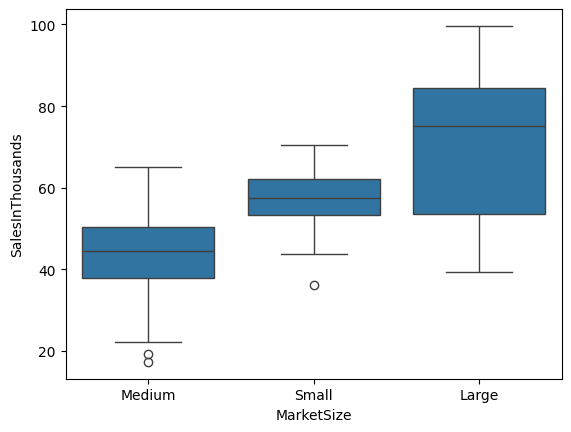

In [12]:
sns.boxplot(x="MarketSize", y="SalesInThousands",data=df)

In [13]:
res = stats.tukey_hsd(medium, small, large, equal_var=False)
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)    -13.424     0.000   -15.789   -11.059
 (0 - 2)    -26.131     0.000   -29.458   -22.805
 (1 - 0)     13.424     0.000    11.059    15.789
 (1 - 2)    -12.707     0.000   -16.411    -9.004
 (2 - 0)     26.131     0.000    22.805    29.458
 (2 - 1)     12.707     0.000     9.004    16.411



Видим, что средние всех групп отличаются между собой. Таким образом, продажи в marketSize == large самые высокие.

Посмотрим зависимость продаж от "новизны" магазина:

AgeOfStore
1     80
4     44
5     44
8     40
7     40
6     36
3     32
9     28
12    24
10    24
Name: count, dtype: int64

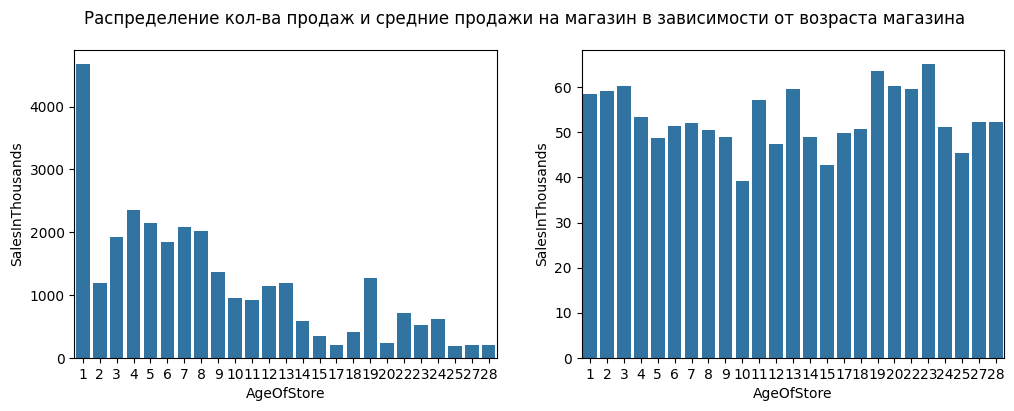

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=df.groupby('AgeOfStore', as_index=False).SalesInThousands.sum(), x='AgeOfStore', y='SalesInThousands', ax=ax[0])
sns.barplot(data=df.groupby('AgeOfStore', as_index=False).SalesInThousands.mean(), x='AgeOfStore', y='SalesInThousands', ax=ax[1])
plt.suptitle('Распределение кол-ва продаж и средние продажи на магазин в зависимости от возраста магазина')
df.AgeOfStore.value_counts()[:10]

Распределение +- равномерное, зависимостей не наблюдается.

Воспользуемся двухфакторым дисперсионным анализом для определения взамодействия факторов MarketSize и Promotion.

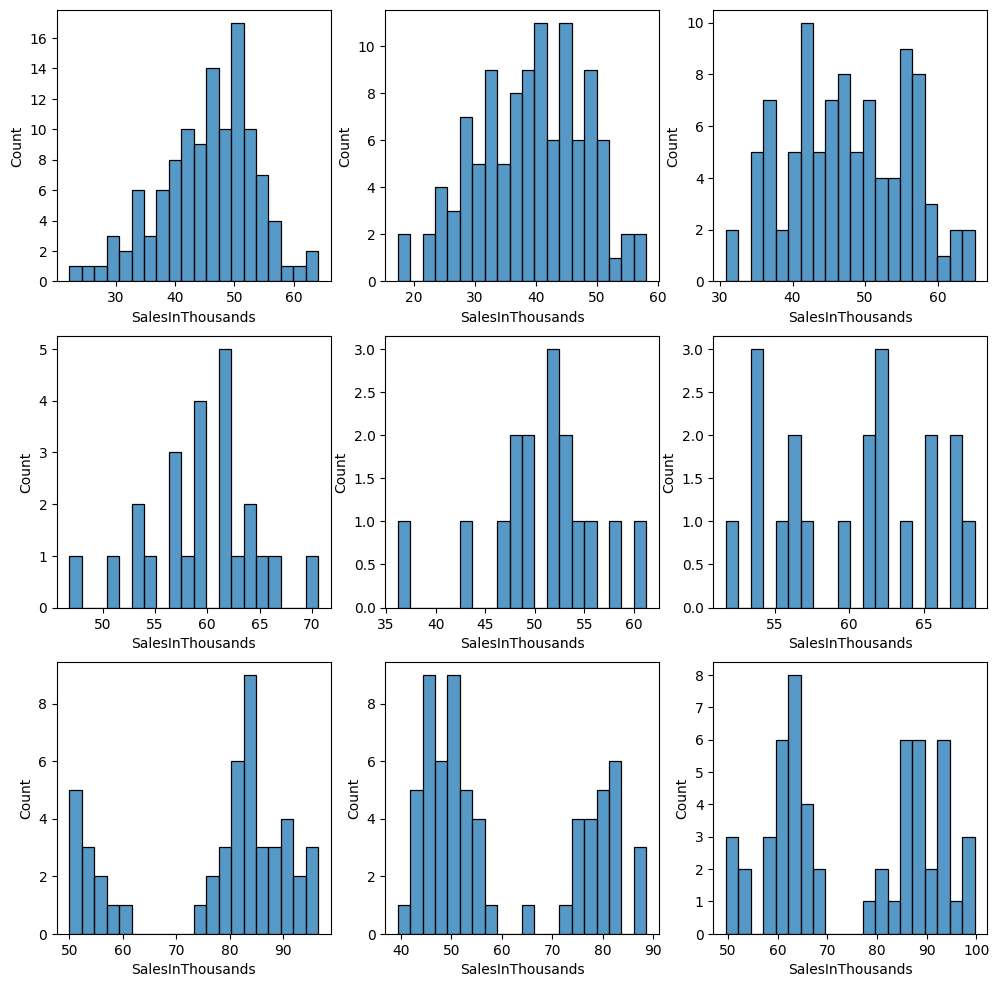

In [15]:
fig, ax = plt.subplots(3, 3, figsize=(12, 12))

for i, ms in enumerate(df.MarketSize.unique()):
    for j, pr in enumerate(df.Promotion.unique()):
        sns.histplot(df[(df.MarketSize == ms) & (df.Promotion == pr)].SalesInThousands, bins=20, ax=ax[i, j])

In [16]:
pg.anova(data=df, between=['MarketSize', 'Promotion'], dv='SalesInThousands', detailed=True)

,Source,SS,DF,MS,F,p-unc,np2
0,MarketSize,77803.041539,2.0,38901.520769,337.135582,1.087739e-95,0.555746
1,Promotion,12979.270759,2.0,6489.635380,56.241683,6.549744e-23,0.172657
2,MarketSize * Promotion,2116.739627,4.0,529.184907,4.586120,1.194444e-03,0.032914
3,Residual,62194.324249,539.0,115.388357,NaN,NaN,NaN


Таким образом MarketSize, Promotion их взаимодействие оказались значимыми, но я бы не стал доверять этому тесту по той причене, что в некоторых группах данных слишком мало для получения осмысленных результатов.

В принципе, влияние MarketSize и так доказано. А для определения влияние Promotion и проводился A/B тест.

---

Определим, какую рекламная кампанию В ЦЕЛОМ показала лучшием метрики. Проверим, есть ли разница вообще между ними:

In [17]:
medium = df[df.MarketSize == 'Medium']
small = df[df.MarketSize == 'Small']
large = df[df.MarketSize == 'Large']

promotion_1 = df[df.Promotion == 1]
promotion_2 = df[df.Promotion == 2]
promotion_3 = df[df.Promotion == 3]

In [18]:
df.groupby('Promotion').agg(
    m=('SalesInThousands', pd.Series.mean),
    s=('SalesInThousands', pd.Series.sum)
)

,m,s
Promotion,,
1,58.099012,9993.03
2,47.329415,8897.93
3,55.364468,10408.52


In [19]:
pg.normality(promotion_1.SalesInThousands), pg.normality(promotion_2.SalesInThousands), pg.normality(promotion_3.SalesInThousands), 

(                       W          pval  normal
 SalesInThousands  0.9153  1.977265e-08   False,
                         W          pval  normal
 SalesInThousands  0.91451  5.457100e-09   False,
                          W          pval  normal
 SalesInThousands  0.920768  1.499466e-08   False)

Text(0.5, 0.98, 'Распределение продаж в зависимости от типа рекламной акции')

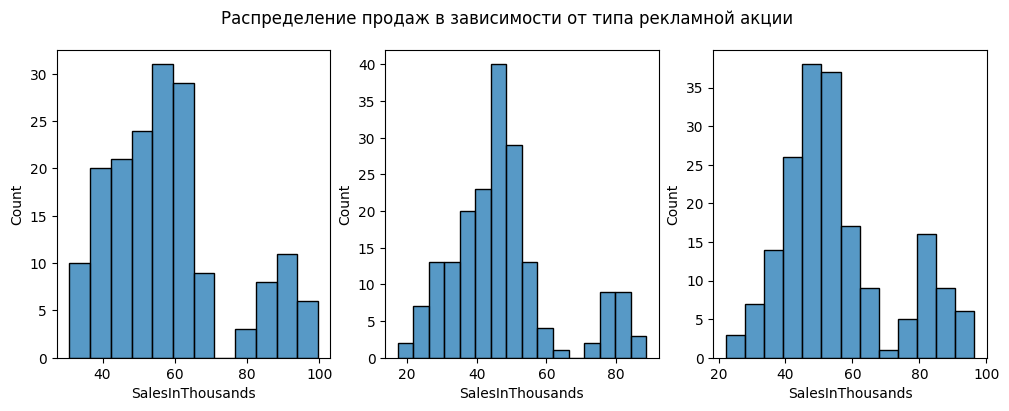

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

sns.histplot(promotion_1.SalesInThousands, ax=ax[0])
sns.histplot(promotion_2.SalesInThousands, ax=ax[1])
sns.histplot(promotion_3.SalesInThousands, ax=ax[2])
plt.suptitle('Распределение продаж в зависимости от типа рекламной акции')

Данные отличаются от нормальных. В целом, anova устойчив к невыполению этого условия. Но воспользуемся его непараметрическим аналогом.

In [21]:
stats.kruskal(
    promotion_1.SalesInThousands,
    promotion_2.SalesInThousands,
    promotion_3.SalesInThousands,
)

KruskalResult(statistic=np.float64(53.29475169322799), pvalue=np.float64(2.6741866266697816e-12))

Есть различия между какими-то группами. Воспользуемся тестом Данна для определения этих групп.

In [22]:
posthoc_dunn(df,group_col='Promotion', val_col='SalesInThousands', p_adjust='holm')

,1,2,3
1,1.000000e+00,6.461842e-12,4.862200e-02
2,6.461842e-12,1.000000e+00,4.722046e-07
3,4.862200e-02,4.722046e-07,1.000000e+00


Среднее кол-во продаж больше всего у магазинов с рекламной акцей под номером 1.

---

Т.к. ранее было выяснено, что MarketSize влияет на продажи, проверим, как действие оказывает promotion на группы с разным MarketSize.

Разберемся сначала с MarketSize == medium. Т.к. в этой группе довольно таки много объектов, восользуемся anova для того, чтобы определить, есть ли разница между группами. Проверим нормальность и гомогенность дисперсий.

In [23]:
pg.normality(medium[medium.Promotion == 1].SalesInThousands), pg.normality(medium[medium.Promotion == 2].SalesInThousands), pg.normality(medium[medium.Promotion == 3].SalesInThousands)

(                         W      pval  normal
 SalesInThousands  0.978888  0.124126    True,
                          W      pval  normal
 SalesInThousands  0.988207  0.466497    True,
                          W      pval  normal
 SalesInThousands  0.983024  0.150679    True)

In [24]:
stats.levene(
    medium[medium.Promotion == 1].SalesInThousands,
    medium[medium.Promotion == 2].SalesInThousands,
    medium[medium.Promotion == 3].SalesInThousands,
)

LeveneResult(statistic=np.float64(0.8597064595109022), pvalue=np.float64(0.42427080965685365))

In [25]:
stats.f_oneway(
    medium[medium.Promotion == 1].SalesInThousands,
    medium[medium.Promotion == 2].SalesInThousands,
    medium[medium.Promotion == 3].SalesInThousands,
)

F_onewayResult(statistic=np.float64(29.688133750845317), pvalue=np.float64(1.519740497160444e-12))

In [26]:
print(
    stats.tukey_hsd(
        medium[medium.Promotion == 1].SalesInThousands,
        medium[medium.Promotion == 2].SalesInThousands,
        medium[medium.Promotion == 3].SalesInThousands,
    )
)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      8.558     0.000     5.806    11.311
 (0 - 2)      2.204     0.136    -0.504     4.911
 (1 - 0)     -8.558     0.000   -11.311    -5.806
 (1 - 2)     -6.355     0.000    -8.978    -3.731
 (2 - 0)     -2.204     0.136    -4.911     0.504
 (2 - 1)      6.355     0.000     3.731     8.978



In [27]:
medium.groupby('Promotion').SalesInThousands.mean()

Promotion
1    47.672604
2    39.114352
3    45.468879
Name: SalesInThousands, dtype: float64

Можно сделать вывод, что для магазинов с MarketSize == medium лучше всего подходит Promotion 1 или 3.

С остальными MarketSize разберемся с помощью bootstrap.

In [28]:
def bootstrap(df, n=10000, alpha=0.05):
    p1 = df[df.Promotion == 1].SalesInThousands
    p2 = df[df.Promotion == 2].SalesInThousands
    p3 = df[df.Promotion == 3].SalesInThousands
    g1, g2, g3 = [], [], []

    for i in range(n):
        g1.append(np.random.choice(p1, size=p1.shape[0], replace=True).mean())
        g2.append(np.random.choice(p2, size=p2.shape[0], replace=True).mean())
        g3.append(np.random.choice(p3, size=p3.shape[0], replace=True).mean())
    
    fig = plt.figure(figsize=(16, 6))
    sns.histplot(g1, color='r', alpha=0.5, label='Promotion == 1')
    sns.histplot(g2, color='g', alpha=0.5, label='Promotion == 2')
    sns.histplot(g3, color='b', alpha=0.5, label='Promotion == 3')

    plt.plot(np.mean(g1), 0, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=5)
    plt.plot(np.mean(g2), 0, 'go', markersize=12, markeredgecolor='black', markeredgewidth=5)
    plt.plot(np.mean(g3), 0, 'bo', markersize=12, markeredgecolor='black', markeredgewidth=5)

    plt.axvline(x=np.quantile(g1, alpha/2), color='r', linestyle='--', linewidth=2)
    plt.axvline(x=np.quantile(g1, 1-alpha/2), color='r', linestyle='--', linewidth=2)

    plt.axvline(x=np.quantile(g2, alpha/2), color='g', linestyle='--', linewidth=2)
    plt.axvline(x=np.quantile(g2, 1-alpha/2), color='g', linestyle='--', linewidth=2)

    plt.axvline(x=np.quantile(g3, alpha/2), color='b', linestyle='--', linewidth=2)
    plt.axvline(x=np.quantile(g3, 1-alpha/2), color='b', linestyle='--', linewidth=2)
    
    plt.legend()

MarketSize == small

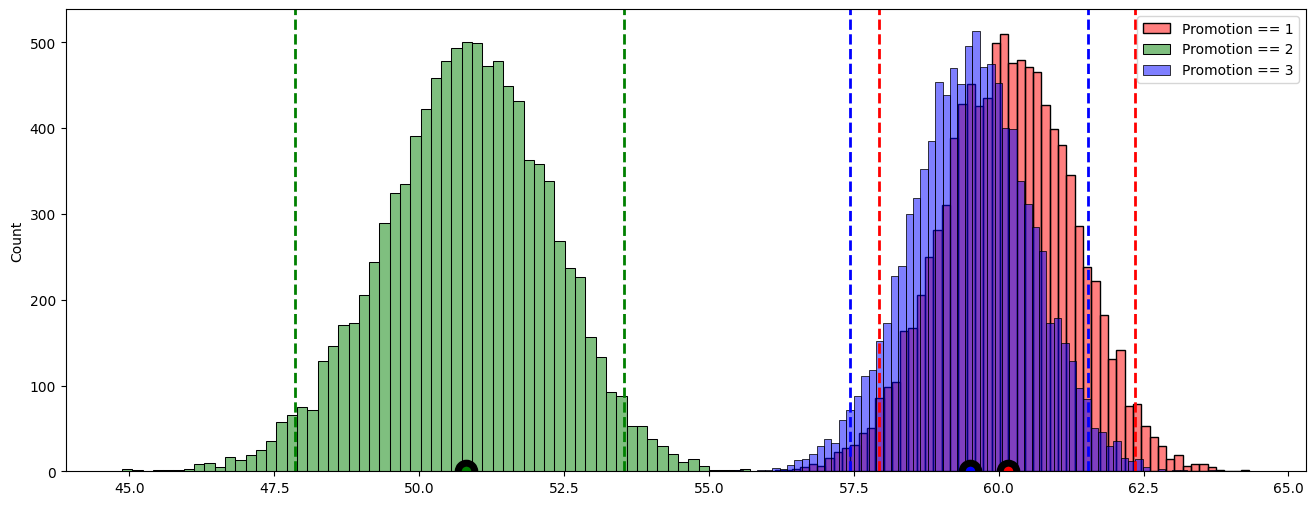

In [29]:
bootstrap(small)

Между Promotion == 1 и Promotion == 3 нет статзначимых различий. Но они оба статзначимо отличаются от Promotion_2.

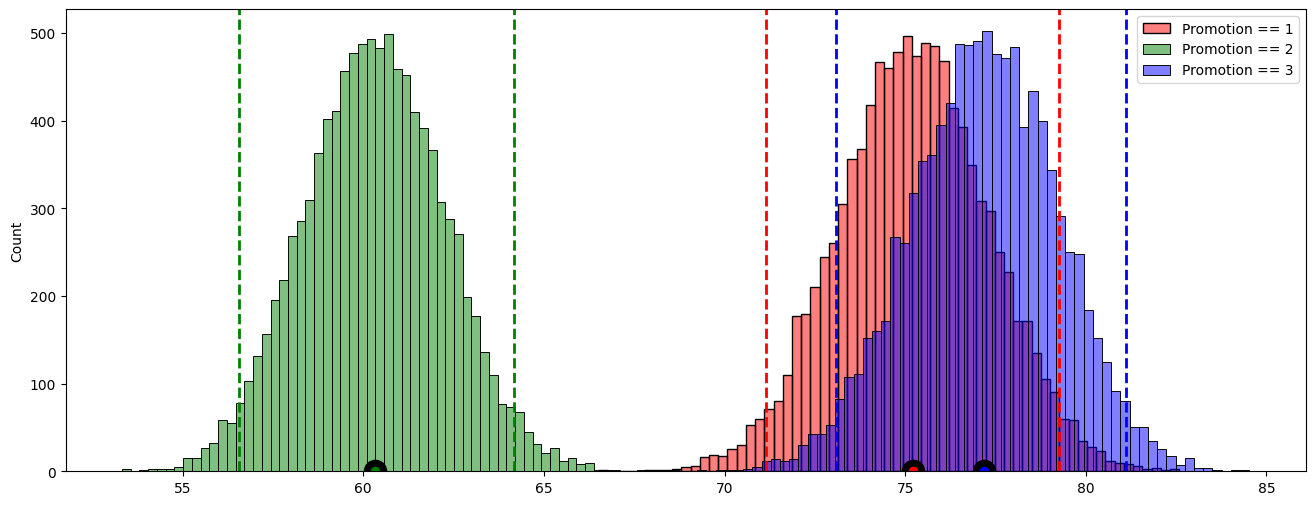

In [30]:
bootstrap(large)

Аналогичная ситуация и с MarketSize == Large

Во всех группах значимых различий между Promotion == 1 и Promotion == 3 нет, но Promotion == 2 показывает себя статзначимо хуже остальных. Учитывая результат теста на всех данных(без разбивки на MarketSize), выбираем Promotion == 1.